# 03 Training Ablation Experiments

## 1. Goal

We compare different training choices for a tiny Arabic->English Transformer, grouped into six
categories (training objective, regularization, optimization, architecture, data, and a combined
model). Each experiment changes one thing. The notebook is runnable from scratch, but by default it loads the saved checkpoints and
results and only shows/plots them, set the flags below to actually retrain.

## 2. Imports and run flags

We import the libraries we need and fix the random seed so the runs stay repeatable.

In [1]:
import os, math, random
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import sacrebleu, sentencepiece as spm

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
torch.set_num_threads(8)
torch.manual_seed(42)
os.makedirs("outputs/figures", exist_ok=True)

These flags decide what runs. By default the notebook only loads saved results, so nothing is retrained or re scored.

In [2]:
# Default: load everything, train nothing. Flip these to rerun.
RUN_TRAINING = False     # train missing / resume incomplete experiments
RUN_DECODING = False     # recompute each model's subset BLEU instead of loading it
AUTO_RESUME = True       # resume from latest.pt if an experiment is incomplete
FORCE_RESTART = False     # ignore existing checkpoints and retrain from scratch
print("RUN_TRAINING", RUN_TRAINING, "| RUN_DECODING", RUN_DECODING,
      "| AUTO_RESUME", AUTO_RESUME, "| FORCE_RESTART", FORCE_RESTART)

RUN_TRAINING False | RUN_DECODING False | AUTO_RESUME True | FORCE_RESTART False


## 3. Dataset loading

We load the Arabic and English tokenizers and build the token to index tables.

In [3]:
sp_ar = spm.SentencePieceProcessor(model_file="Data/vocab/sp_ar.model")
sp_en = spm.SentencePieceProcessor(model_file="Data/vocab/sp_en.model")
ar_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_ar.vocab", encoding="utf-8").read().splitlines() if l]
en_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_en.vocab", encoding="utf-8").read().splitlines() if l]
ar_stoi = {t: i for i, t in enumerate(ar_tokens)}
en_itos = {i: t for i, t in enumerate(en_tokens)}
ar_pad, en_pad = ar_stoi["<pad>"], en_tokens.index("<pad>")
en_bos, en_eos = en_tokens.index("<s>"), en_tokens.index("</s>")

Small helpers that turn BPE pieces into ids and read a data file.

In [4]:
def encode(pieces, stoi):
    return [stoi["<s>"]] + [stoi.get(p, stoi["<unk>"]) for p in pieces] + [stoi["</s>"]]

def read_bpe(p):
    return [l.split() for l in open(p, encoding="utf-8").read().splitlines()]

def load_pairs(src, tgt):
    return [(encode(a, ar_stoi), encode(e, en_stoi)) for a, e in zip(read_bpe(src), read_bpe(tgt))
            if len(a) <= 80 and len(e) <= 80]

We load the data. The training and validation sets only load when we actually train, while the test subset is always ready for scoring.

In [5]:
# training data is only needed when RUN_TRAINING=True; the test subset is always used for scoring
train_pairs = load_pairs("Data/tokenized/train.ar.bpe", "Data/tokenized/train.en.bpe") if RUN_TRAINING else []
val_pairs = load_pairs("Data/tokenized/validation.ar.bpe", "Data/tokenized/validation.en.bpe") if RUN_TRAINING else []
test = [(a, e) for a, e in zip(read_bpe("Data/tokenized/test.ar.bpe"), read_bpe("Data/tokenized/test.en.bpe"))
        if len(a) <= 80 and len(e) <= 80][:1000]
sub_src = [" ".join(a) for a, e in test]
sub_ref = [sp_en.decode(e) for a, e in test]
sources = [sp_ar.decode(a) for a, e in test]
print("test subset:", len(sub_src), "| train pairs loaded:", len(train_pairs))

test subset: 1000 | train pairs loaded: 0


Two helper sets used only by the data and curriculum experiments below: a copy of the training data with rare-word sentences duplicated, and the training data sorted from short to long.

In [6]:
# extra training sets, only built when training: rare-word oversampling and a length-sorted order
if RUN_TRAINING:
    from collections import Counter
    _freq = Counter(tok for s, t in train_pairs for tok in t)
    _rare = {tok for tok, c in _freq.items() if c < 5}
    rare_aug_pairs = train_pairs + [p for p in train_pairs if _rare & set(p[1])]
    by_len = sorted(train_pairs, key=lambda p: len(p[0]))
else:
    rare_aug_pairs, by_len = [], []

## 4. Base model configuration

The base configuration. Every experiment starts from this and changes just one setting.

In [7]:
base_config = {
    "name": "baseline (Adam)",
    "category": "Reference",
    "d_model": 128,
    "num_layers": 2,
    "n_heads": 4,
    "dim_feedforward": 512,
    "dropout": 0.1,
    "optimizer": "Adam",
    "learning_rate": 3e-4,
    "weight_decay": 0.0,
    "loss": "cross_entropy",
    "label_smoothing": 0.0,
    "focal_gamma": 2.0,
    "scheduler": "none",
    "tie_weights": False,
    "epochs": 60,
    "activation": "relu",
    "train_size": None,
    "augment": None,
    "curriculum": False,
    "rdrop_alpha": 0.0,
    "checkpoint_dir": "outputs/checkpoints/baseline",
}
base_config

{'name': 'baseline (Adam)',
 'category': 'Reference',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/baseline'}

## 5. Minimal model definition

The positional encoding, which tells the model the position of each token.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

The tiny Transformer model used in every experiment.

In [9]:
class TinyTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.src_pad_id, self.tgt_pad_id, self.d_model = ar_pad, en_pad, cfg["d_model"]
        self.src_embedding = nn.Embedding(len(ar_tokens), cfg["d_model"], padding_idx=ar_pad)
        self.tgt_embedding = nn.Embedding(len(en_tokens), cfg["d_model"], padding_idx=en_pad)
        self.positional_encoding = PositionalEncoding(cfg["d_model"], cfg["dropout"], 82)
        self.transformer = nn.Transformer(cfg["d_model"], cfg["n_heads"], cfg["num_layers"], cfg["num_layers"],
                                          cfg["dim_feedforward"], cfg["dropout"], batch_first=True,
                                          activation=cfg.get("activation", "relu"))
        self.output_projection = nn.Linear(cfg["d_model"], len(en_tokens))
        if cfg["tie_weights"]:
            self.output_projection.weight = self.tgt_embedding.weight

    def forward(self, src, tgt_in):
        m = torch.triu(torch.ones(tgt_in.size(1), tgt_in.size(1), dtype=torch.bool), diagonal=1)
        sk, tk = src.eq(self.src_pad_id), tgt_in.eq(self.tgt_pad_id)
        se = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        te = self.positional_encoding(self.tgt_embedding(tgt_in) * math.sqrt(self.d_model))
        h = self.transformer(se, te, tgt_mask=m, src_key_padding_mask=sk, tgt_key_padding_mask=tk, memory_key_padding_mask=sk)
        return self.output_projection(h)

## 6. Training and scoring utilities
A few small helpers, used by every experiment below.

Helpers that build padded batches and compute the loss for an experiment.

In [10]:
def make_batches(pairs):
    order = list(range(len(pairs))); random.shuffle(order)
    for i in range(0, len(order), 32):
        chunk = [pairs[j] for j in order[i:i + 32]]
        sm = max(len(s) for s, t in chunk); tm = max(len(t) for s, t in chunk)
        src = torch.full((len(chunk), sm), ar_pad); tgt = torch.full((len(chunk), tm), en_pad)
        for r, (s, t) in enumerate(chunk):
            src[r, :len(s)] = torch.tensor(s); tgt[r, :len(t)] = torch.tensor(t)
        yield src, tgt

def compute_loss(logits, tgt, cfg):
    if cfg["loss"] == "focal":
        lp = F.log_softmax(logits, -1).gather(1, tgt.unsqueeze(1)).squeeze(1)
        return (-((1 - lp.exp()) ** cfg["focal_gamma"]) * lp)[tgt.ne(en_pad)].mean()
    return F.cross_entropy(logits, tgt, ignore_index=en_pad, label_smoothing=cfg["label_smoothing"])

The validation loss, and one full training epoch.

In [11]:
def evaluate_loss(model, pairs):
    model.eval(); tot = ntok = 0
    with torch.no_grad():
        for i in range(0, len(pairs), 32):
            chunk = pairs[i:i + 32]
            sm = max(len(s) for s, t in chunk); tm = max(len(t) for s, t in chunk)
            src = torch.full((len(chunk), sm), ar_pad); tgt = torch.full((len(chunk), tm), en_pad)
            for r, (s, t) in enumerate(chunk):
                src[r, :len(s)] = torch.tensor(s); tgt[r, :len(t)] = torch.tensor(t)
            gold = tgt[:, 1:].reshape(-1)
            ce = F.cross_entropy(model(src, tgt[:, :-1]).reshape(-1, len(en_tokens)), gold, ignore_index=en_pad)
            k = gold.ne(en_pad).sum().item(); tot += ce.item() * k; ntok += k
    return tot / max(1, ntok)

def epoch_pairs(cfg, epoch):
    if cfg["train_size"]:                                   # data-size ablation: a fixed random subset
        return random.Random(42).sample(train_pairs, cfg["train_size"])
    if cfg["augment"] == "rare":                            # rare-word oversampling
        return rare_aug_pairs
    if cfg["curriculum"]:                                   # competence c(t)=min(1, sqrt(t/0.5T)): easy first
        c = min(1.0, math.sqrt(epoch / (0.5 * cfg["epochs"])))
        return list(by_len[: max(32, int(c * len(by_len)))])
    return train_pairs

def train_one_epoch(model, opt, cfg, sched, step, epoch):
    model.train(); last = 0.0
    for src, gold in make_batches(epoch_pairs(cfg, epoch)):
        tin, tgt = gold[:, :-1], gold[:, 1:].reshape(-1)
        if cfg["scheduler"] == "warmup":
            step[0] += 1; opt.param_groups[0]["lr"] = cfg["learning_rate"] * min(step[0] / 2000, (2000 / step[0]) ** 0.5)
        if cfg["rdrop_alpha"]:                              # R-Drop: two dropout views + symmetric KL
            l1 = model(src, tin).reshape(-1, len(en_tokens)); l2 = model(src, tin).reshape(-1, len(en_tokens))
            ce = 0.5 * (compute_loss(l1, tgt, cfg) + compute_loss(l2, tgt, cfg))
            mask = tgt.ne(en_pad); p1, p2 = F.log_softmax(l1, -1), F.log_softmax(l2, -1)
            kl = 0.5 * (F.kl_div(p1, p2.exp(), reduction="none") + F.kl_div(p2, p1.exp(), reduction="none")).sum(-1)
            loss = ce + cfg["rdrop_alpha"] * kl[mask].mean()
        else:
            loss = compute_loss(model(src, tin).reshape(-1, len(en_tokens)), tgt, cfg)
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        if sched: sched.step()
        last = loss.item()
    return last

The single function every experiment calls. It loads a finished checkpoint, resumes an unfinished one, or trains from scratch when the flags allow it.

In [12]:
def load_or_train_checkpoint(cfg):
    best = f"{cfg['checkpoint_dir']}/best.pt"; latest = f"{cfg['checkpoint_dir']}/latest.pt"
    model = TinyTransformer(cfg)
    if os.path.exists(best) and not FORCE_RESTART:                 # completed -> load
        state = torch.load(best, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state_dict"]); model.eval()
        return model, state.get("history", [])
    if not RUN_TRAINING:
        raise RuntimeError(f"{cfg['name']}: no checkpoint and RUN_TRAINING=False. Set RUN_TRAINING=True to train it.")
    os.makedirs(cfg["checkpoint_dir"], exist_ok=True)
    opt = (torch.optim.AdamW if cfg["optimizer"] == "AdamW" else torch.optim.Adam)(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["epochs"] * math.ceil(len(train_pairs) / 32)) \
        if cfg["scheduler"] == "cosine" else None
    start, best_val, history, step = 1, float("inf"), [], [0]
    if AUTO_RESUME and os.path.exists(latest) and not FORCE_RESTART:   # incomplete -> resume
        ck = torch.load(latest, map_location="cpu", weights_only=False)
        model.load_state_dict(ck["model_state_dict"]); start = ck["epoch"] + 1
        best_val, history = ck["best_val_loss"], ck["history"]
    for epoch in range(start, cfg["epochs"] + 1):
        tr = train_one_epoch(model, opt, cfg, sched, step, epoch)
        v = evaluate_loss(model, val_pairs)
        history.append({"epoch": epoch, "train_loss": round(tr, 4), "val_loss": round(v, 4)})
        best_val = min(best_val, v)
        ck = {"model_state_dict": model.state_dict(), "epoch": epoch, "best_val_loss": best_val, "history": history}
        torch.save(ck, latest)
        if v <= best_val:
            torch.save(ck, best)
    model.eval(); return model, history

Beam search decoding. With a beam of one it is simply greedy decoding.

In [13]:
@torch.no_grad()
def beam_decode(model, src_line, beam=3, lp=1.0, nr=3):
    model.eval()
    src = torch.tensor([encode(src_line.split(), ar_stoi)]); pad = src.eq(model.src_pad_id)
    mem = model.transformer.encoder(model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model)),
                                    src_key_padding_mask=pad).expand(beam, -1, -1).contiguous()
    mpad = pad.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), en_bos, dtype=torch.long)
    scores = torch.full((beam,), float("-inf")); scores[0] = 0.0; done = []
    for _ in range(80):
        L = ys.size(1); cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        dec = model.transformer.decoder(model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model)),
                                        mem, tgt_mask=cm, memory_key_padding_mask=mpad)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        for b in range(beam):
            seq = ys[b].tolist()
            if nr and len(seq) >= nr:
                prev = tuple(seq[-(nr - 1):]) if nr > 1 else ()
                ban = [tuple(seq[i:i + nr])[-1] for i in range(len(seq) - nr + 1) if tuple(seq[i:i + nr])[:-1] == prev]
                if ban: logp[b, ban] = float("-inf")
        V = logp.size(-1); s, idx = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(idx, V, rounding_mode="floor")], (idx % V).unsqueeze(1)], 1); scores = s.clone()
        for b in range(beam):
            if (idx[b] % V).item() == en_eos:
                done.append((scores[b].item() / max(1, ys.size(1) - 1) ** lp, ys[b].tolist())); scores[b] = float("-inf")
        if len(done) >= beam or torch.isinf(scores).all():
            break
    if not done:
        done.append((0.0, ys[int(scores.argmax())].tolist()))
    out = max(done, key=lambda x: x[0])[1]
    return sp_en.decode([en_itos.get(int(i), "<unk>") for i in out if int(i) not in (en_pad, en_bos, en_eos)])

Scoring with BLEU and chrF++, a repetition check, and a helper that loads or recomputes each model's subset score.

In [14]:
def score_bleu_chrf(hyps, refs):
    return (round(sacrebleu.corpus_bleu(hyps, [refs]).score, 4),
            round(sacrebleu.corpus_chrf(hyps, [refs], word_order=2).score, 4))

def repetition_rate(hyps):
    n = sum(1 for h in hyps if len(h.split()) >= 4 and
            (len(list(zip(h.split(), h.split()[1:]))) - len(set(zip(h.split(), h.split()[1:]))) >= 2
             or len(set(h.split())) / len(h.split()) < 0.5))
    return round(100 * n / max(1, len(hyps)), 1)

# saved per-experiment scores (loaded by default; recomputed only when RUN_DECODING=True)
saved = {r["experiment"]: r for _, r in pd.read_csv("outputs/tables/training_comparison.csv").iterrows()} \
    if os.path.exists("outputs/tables/training_comparison.csv") else {}

def subset_result(cfg, model):
    if not RUN_DECODING and cfg["name"] in saved:
        r = saved[cfg["name"]]
        return {"experiment": cfg["name"], "category": cfg["category"], "bleu": r["bleu"], "chrf_pp": r["chrf_pp"], "rep_pct": r["rep_pct"]}
    hyps = [beam_decode(model, s) for s in sub_src]
    bleu, chrf = score_bleu_chrf(hyps, sub_ref)
    return {"experiment": cfg["name"], "category": cfg["category"], "bleu": bleu, "chrf_pp": chrf, "rep_pct": repetition_rate(hyps)}

Two small plotting helpers, one for the loss curve and one for the metric bars.

In [15]:
def plot_loss(history, title, save):
    h = pd.DataFrame(history)
    plt.figure(figsize=(5, 3))
    if "train_loss" in h.columns:
        plt.plot(h["epoch"], h["train_loss"], label="train")
    plt.plot(h["epoch"], h["val_loss"], label="validation")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(save); plt.show()

def plot_metric_bars(rows, title, save):
    d = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, m, c in zip(axes, ["bleu", "chrf_pp", "rep_pct"], ["tab:blue", "tab:green", "tab:orange"]):
        ax.bar(d["experiment"], d[m], color=c); ax.set_title(m); ax.tick_params(axis="x", rotation=20)
    fig.suptitle(title); fig.tight_layout(); fig.savefig(save); plt.show()

results = []

### Baseline (reference): plain Adam
The reference model. Every ablation below is compared to it.

The baseline simply uses the base configuration with no changes.

In [16]:
baseline_config = base_config
baseline_config

{'name': 'baseline (Adam)',
 'category': 'Reference',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/baseline'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [17]:
baseline_model, baseline_hist = load_or_train_checkpoint(baseline_config)
print('parameters:', f'{sum(p.numel() for p in baseline_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [18]:
pd.DataFrame(baseline_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
51,52,3.285413,3.983659
52,53,3.279590,3.985661
53,54,3.269566,3.981622
54,55,3.260590,3.979431
55,56,3.252260,3.972247


The training and validation loss across the epochs.

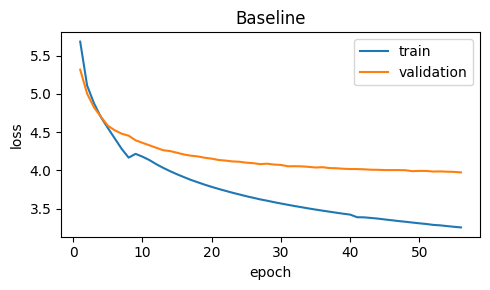

In [19]:
plot_loss(baseline_hist, "Baseline", "outputs/figures/training_baseline_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [20]:
baseline_res = subset_result(baseline_config, baseline_model)
results.append(baseline_res)
pd.DataFrame([baseline_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,baseline (Adam),Reference,7.9885,26.8619,10.1


Just as every experiment below is compared to this baseline Transformer, we first compare the baseline Transformer itself to the non-neural dictionary baseline from notebook 02. The dictionary number is its full-test score; for that simple model the subset and full-test scores agree closely, so the comparison is fair.

In [21]:
dict_base = pd.read_csv("outputs/tables/baseline_results.csv").iloc[0]
baseline_vs_dict = pd.DataFrame([
    {"system": "dictionary baseline", "bleu": round(float(dict_base["bleu"]), 2), "chrf_pp": round(float(dict_base["chrf_pp"]), 2)},
    {"system": "baseline Transformer", "bleu": baseline_res["bleu"], "chrf_pp": baseline_res["chrf_pp"]},
])
baseline_vs_dict

,system,bleu,chrf_pp
0,dictionary baseline,4.7800,25.6500
1,baseline Transformer,7.9885,26.8619


The two metrics for the dictionary baseline and the baseline Transformer, side by side.

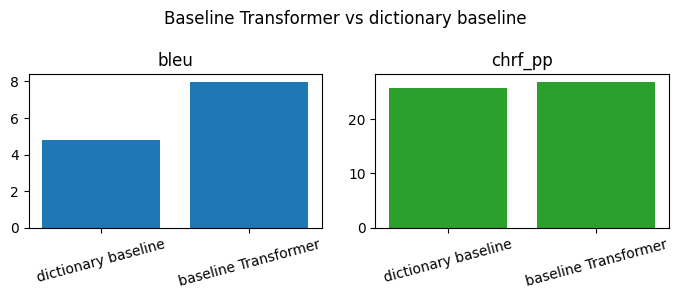

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, m, color in zip(axes, ["bleu", "chrf_pp"], ["tab:blue", "tab:green"]):
    ax.bar(baseline_vs_dict["system"], baseline_vs_dict[m], color=color)
    ax.set_title(m); ax.tick_params(axis="x", rotation=15)
fig.suptitle("Baseline Transformer vs dictionary baseline")
fig.tight_layout(); fig.savefig("outputs/figures/training_baseline_vs_dictionary.png"); plt.show()

The tiny Transformer beats the trivial dictionary baseline on BLEU, but only barely on chrF++. That small margin is exactly what motivates the ablation study: without better regularization and decoding, a from-scratch tiny model is not clearly better than a non-neural lookup.

Greedy/loss is weak and repetitive; this is the floor every other experiment is measured against.

## Experiment A: Training Objective

### A1: Label Smoothing
Cross-entropy with label smoothing 0.1 (softer targets).

The configuration for this experiment. Only the changed line is different from the base.

In [23]:
ls_config = {
    **base_config,
    "name": "Exp 1: label smoothing 0.1",
    "category": "Training objective",
    "label_smoothing": 0.1,
    "checkpoint_dir": "outputs/checkpoints/A_training_objective/exp1_label_smoothing",
}
ls_config

{'name': 'Exp 1: label smoothing 0.1',
 'category': 'Training objective',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.1,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/A_training_objective/exp1_label_smoothing'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [24]:
ls_model, ls_hist = load_or_train_checkpoint(ls_config)
print('parameters:', f'{sum(p.numel() for p in ls_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [25]:
pd.DataFrame(ls_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
54,55,4.236813,4.646530
55,56,4.230708,4.644174
56,57,4.223476,4.640882
57,58,4.218010,4.637732
58,59,4.211822,4.632535


The training and validation loss across the epochs.

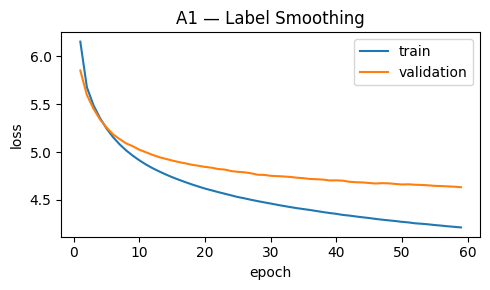

In [26]:
plot_loss(ls_hist, "A1 — Label Smoothing", "outputs/figures/training_A1_label_smoothing_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [27]:
ls_res = subset_result(ls_config, ls_model)
results.append(ls_res)
pd.DataFrame([ls_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 1: label smoothing 0.1,Training objective,9.0322,28.517,13.1


This experiment shown next to the baseline.

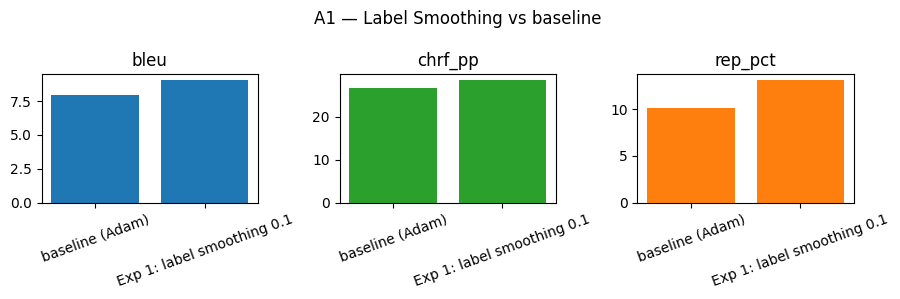

In [28]:
plot_metric_bars([baseline_res, ls_res], "A1 — Label Smoothing vs baseline", "outputs/figures/training_A1_label_smoothing_vs_baseline.png")

Label smoothing helps a little over the baseline under the same decoding.

### A2: Focal Loss
Focal loss (gamma=2) down-weights easy, confident tokens.

The configuration for this experiment. Only the changed line is different from the base.

In [29]:
focal_config = {
    **base_config,
    "name": "Exp 2: focal loss",
    "category": "Training objective",
    "loss": "focal",
    "checkpoint_dir": "outputs/checkpoints/A_training_objective/exp2_focal_loss",
}
focal_config

{'name': 'Exp 2: focal loss',
 'category': 'Training objective',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'focal',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/A_training_objective/exp2_focal_loss'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [30]:
focal_model, focal_hist = load_or_train_checkpoint(focal_config)
print('parameters:', f'{sum(p.numel() for p in focal_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [31]:
pd.DataFrame(focal_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
54,55,2.9952,3.9890
55,56,2.9862,3.9786
56,57,2.9754,3.9842
57,58,2.9686,3.9793
58,59,2.9608,3.9772


The training and validation loss across the epochs.

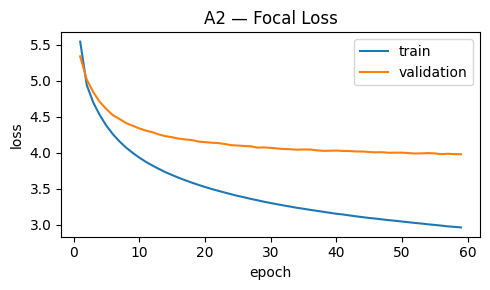

In [32]:
plot_loss(focal_hist, "A2 — Focal Loss", "outputs/figures/training_A2_focal_loss_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [33]:
focal_res = subset_result(focal_config, focal_model)
results.append(focal_res)
pd.DataFrame([focal_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 2: focal loss,Training objective,8.1698,27.3715,10.3


This experiment shown next to the baseline.

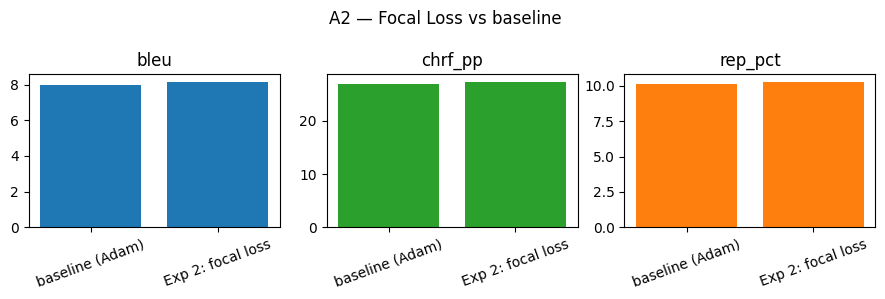

In [34]:
plot_metric_bars([baseline_res, focal_res], "A2 — Focal Loss vs baseline", "outputs/figures/training_A2_focal_loss_vs_baseline.png")

Focal loss is roughly on par with the baseline here.

## Experiment B: Regularization

### B1: Dropout 0.3
Dropout raised from 0.1 to 0.3.

The configuration for this experiment. Only the changed line is different from the base.

In [35]:
drop_config = {
    **base_config,
    "name": "Exp 1: dropout 0.3",
    "category": "Regularization",
    "dropout": 0.3,
    "checkpoint_dir": "outputs/checkpoints/B_regularization/exp1_dropout",
}
drop_config

{'name': 'Exp 1: dropout 0.3',
 'category': 'Regularization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.3,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/B_regularization/exp1_dropout'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [36]:
drop_model, drop_hist = load_or_train_checkpoint(drop_config)
print('parameters:', f'{sum(p.numel() for p in drop_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [37]:
pd.DataFrame(drop_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.902268,4.204961
56,57,3.893881,4.204088
57,58,3.887652,4.191440
58,59,3.880429,4.189910
59,60,3.872699,4.185242


The training and validation loss across the epochs.

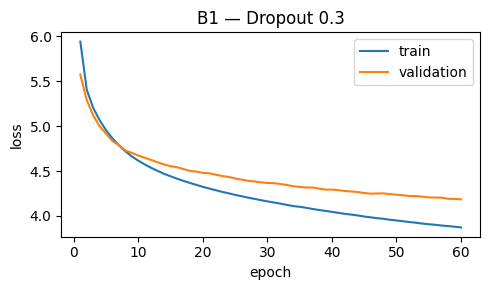

In [38]:
plot_loss(drop_hist, "B1 — Dropout 0.3", "outputs/figures/training_B1_dropout_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [39]:
drop_res = subset_result(drop_config, drop_model)
results.append(drop_res)
pd.DataFrame([drop_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 1: dropout 0.3,Regularization,6.0312,23.6215,16.7


This experiment shown next to the baseline.

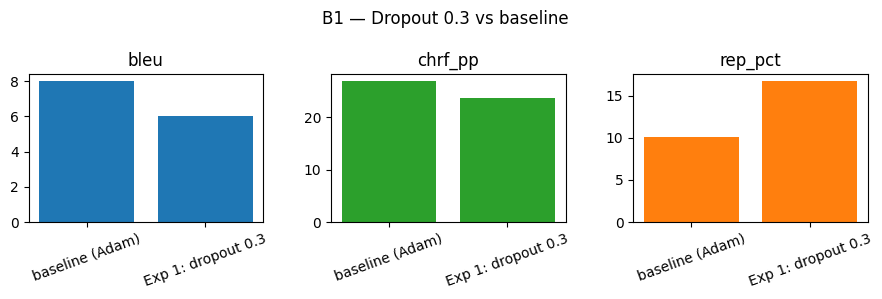

In [40]:
plot_metric_bars([baseline_res, drop_res], "B1 — Dropout 0.3 vs baseline", "outputs/figures/training_B1_dropout_vs_baseline.png")

Dropout 0.3 over-regularizes this small model and hurts.

### B2: Weight Decay 1e-4
Adam with L2 weight decay 1e-4. This is the strongest single change.

The configuration for this experiment. Only the changed line is different from the base.

In [41]:
wd_config = {
    **base_config,
    "name": "Exp 2: weight decay 1e-4",
    "category": "Regularization",
    "weight_decay": 1e-4,
    "checkpoint_dir": "outputs/checkpoints/B_regularization/exp2_weight_decay",
}
wd_config

{'name': 'Exp 2: weight decay 1e-4',
 'category': 'Regularization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/B_regularization/exp2_weight_decay'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [42]:
wd_model, wd_hist = load_or_train_checkpoint(wd_config)
print('parameters:', f'{sum(p.numel() for p in wd_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [43]:
pd.DataFrame(wd_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
52,53,2.4741,2.8098
53,54,2.4705,2.8047
54,55,2.4675,2.7980
55,56,2.4654,2.7871
56,57,2.4631,2.7842


The training and validation loss across the epochs.

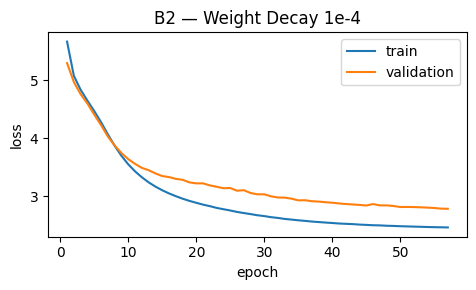

In [44]:
plot_loss(wd_hist, "B2 — Weight Decay 1e-4", "outputs/figures/training_B2_weight_decay_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [45]:
wd_res = subset_result(wd_config, wd_model)
results.append(wd_res)
pd.DataFrame([wd_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 2: weight decay 1e-4,Regularization,18.7879,41.0371,4.8


This experiment shown next to the baseline.

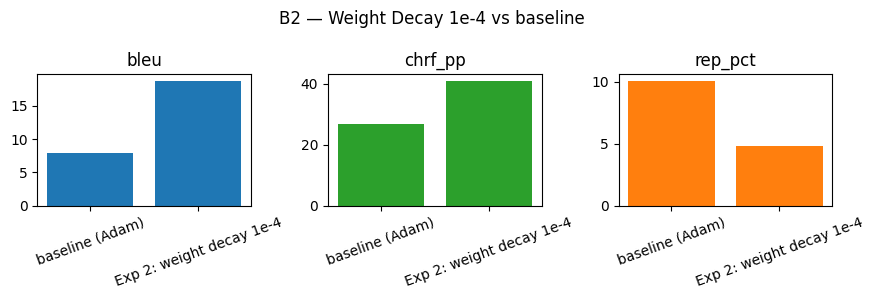

In [46]:
plot_metric_bars([baseline_res, wd_res], "B2 — Weight Decay 1e-4 vs baseline", "outputs/figures/training_B2_weight_decay_vs_baseline.png")

Weight decay is by far the best result, it removes the degenerate repetition.

### B3: Same-code Control: weight_decay = 0
Identical to B2 but with weight decay OFF. This isolates whether the B2 gain is the weight decay or just the training code.

The configuration for this experiment. Only the changed line is different from the base.

In [47]:
control_config = {
    **base_config,
    "name": "B3 control (weight_decay=0)",
    "category": "Regularization",
    "weight_decay": 0.0,
    "checkpoint_dir": "outputs/checkpoints/_control/newcode_baseline_wd0",
}
control_config

{'name': 'B3 control (weight_decay=0)',
 'category': 'Regularization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/_control/newcode_baseline_wd0'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [48]:
control_model, control_hist = load_or_train_checkpoint(control_config)
print('parameters:', f'{sum(p.numel() for p in control_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [49]:
pd.DataFrame(control_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,val_loss
52,53,3.9675
53,54,3.9684
54,55,3.9688
55,56,3.9572
56,57,3.9565


The training and validation loss across the epochs.

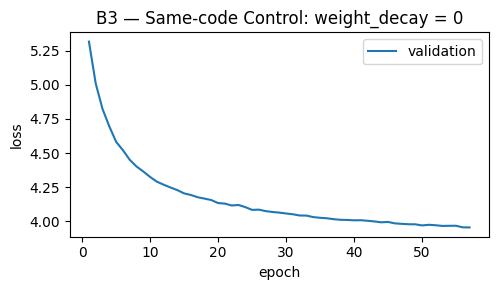

In [50]:
plot_loss(control_hist, "B3 — Same-code Control: weight_decay = 0", "outputs/figures/training_B3_control_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [51]:
control_res = subset_result(control_config, control_model)
results.append(control_res)
pd.DataFrame([control_res])

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


,experiment,category,bleu,chrf_pp,rep_pct
0,B3 control (weight_decay=0),Regularization,8.2268,27.648,10.1


This experiment shown next to the baseline.

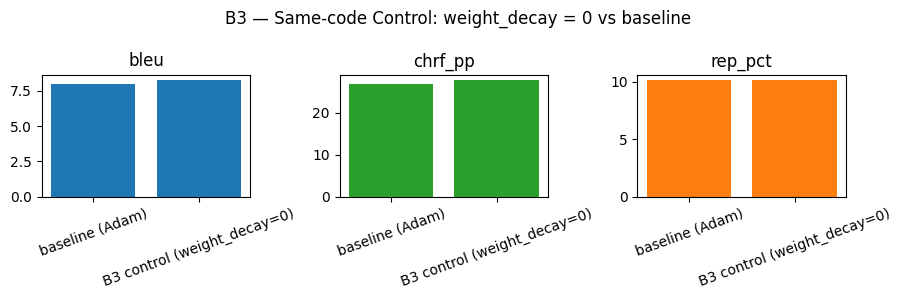

In [52]:
plot_metric_bars([baseline_res, control_res], "B3 — Same-code Control: weight_decay = 0 vs baseline", "outputs/figures/training_B3_control_vs_baseline.png")

The control lands at val ~4.0, like the plain baseline, so the B2 gain is genuinely the weight decay, not a pipeline artifact.

### B2 vs B3: does weight decay cause the gain?

The validation loss of weight decay against the control, on one chart.

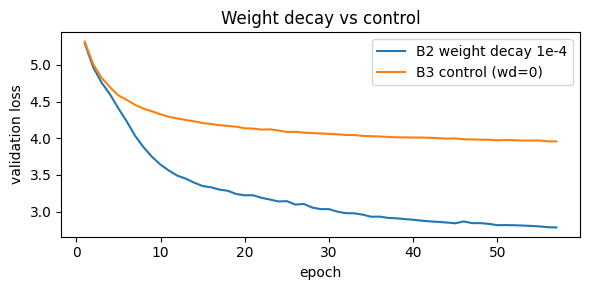

In [53]:
b2 = pd.DataFrame(wd_hist); b3 = pd.DataFrame(control_hist)
plt.figure(figsize=(6, 3))
plt.plot(b2["epoch"], b2["val_loss"], label="B2 weight decay 1e-4")
plt.plot(b3["epoch"], b3["val_loss"], label="B3 control (wd=0)")
plt.xlabel("epoch"); plt.ylabel("validation loss"); plt.title("Weight decay vs control"); plt.legend()
plt.tight_layout(); plt.savefig("outputs/figures/training_B2_vs_control_loss.png"); plt.show()

Weight decay against the control on all three metrics.

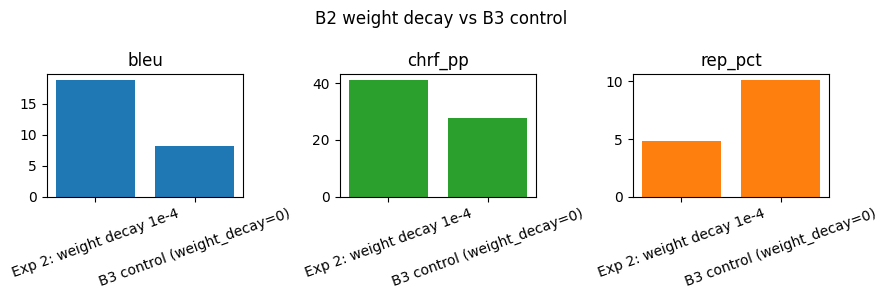

In [54]:
plot_metric_bars([wd_res, control_res], "B2 weight decay vs B3 control", "outputs/figures/training_B2_vs_control_metrics.png")

Same code, same data, only the weight decay differs. B2 reaches ~2.8 and B3 ~4.0, so weight decay is the cause.

### B4: R-Drop

R-Drop is the third regularization idea. Each batch is passed through the model twice with different dropout masks, and a symmetric KL term pushes the two predictions to agree.

In [55]:
rdrop_config = {**base_config, "name": "Exp 3: R-Drop", "category": "Regularization",
              "rdrop_alpha": 0.7, "checkpoint_dir": "outputs/checkpoints/B_regularization/exp3_rdrop"}
rdrop_config

{'name': 'Exp 3: R-Drop',
 'category': 'Regularization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.7,
 'checkpoint_dir': 'outputs/checkpoints/B_regularization/exp3_rdrop'}

We load this model, or train it if the flags are on, and print its parameter count.

In [56]:
rdrop_model, rdrop_hist = load_or_train_checkpoint(rdrop_config)
print('parameters:', f'{sum(p.numel() for p in rdrop_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [57]:
pd.DataFrame(rdrop_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.3985,3.8783
56,57,3.3917,3.8745
57,58,3.3837,3.8721
58,59,3.3749,3.8710
59,60,3.3676,3.8649


The training and validation loss across the epochs.

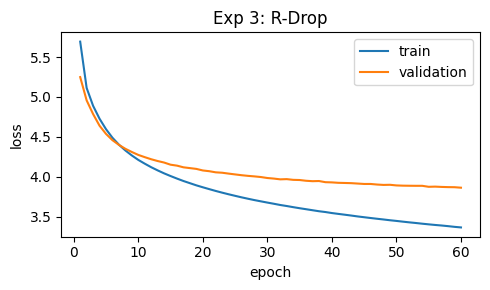

In [58]:
plot_loss(rdrop_hist, "Exp 3: R-Drop", "outputs/figures/training_B4_rdrop_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [59]:
rdrop_res = subset_result(rdrop_config, rdrop_model)
results.append(rdrop_res)
pd.DataFrame([rdrop_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 3: R-Drop,Regularization,7.9508,26.9164,11.6


Consistency regularization on top of dropout. We read its BLEU and repetition against the baseline.

## Experiment C: Optimization

### C1: AdamW
AdamW (decoupled weight decay).

The configuration for this experiment. Only the changed line is different from the base.

In [60]:
adamw_config = {
    **base_config,
    "name": "Exp 1: AdamW wd 1e-4",
    "category": "Optimization",
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "checkpoint_dir": "outputs/checkpoints/C_optimization/exp1_adamw",
}
adamw_config

{'name': 'Exp 1: AdamW wd 1e-4',
 'category': 'Optimization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/C_optimization/exp1_adamw'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [61]:
adamw_model, adamw_hist = load_or_train_checkpoint(adamw_config)
print('parameters:', f'{sum(p.numel() for p in adamw_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [62]:
pd.DataFrame(adamw_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.249442,3.967745
56,57,3.241688,3.971539
57,58,3.233316,3.973439
58,59,3.225965,3.968910
59,60,3.218437,3.965900


The training and validation loss across the epochs.

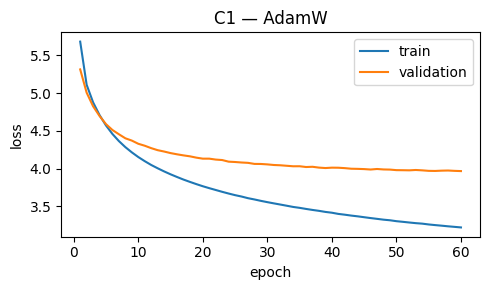

In [63]:
plot_loss(adamw_hist, "C1 — AdamW", "outputs/figures/training_C1_adamw_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [64]:
adamw_res = subset_result(adamw_config, adamw_model)
results.append(adamw_res)
pd.DataFrame([adamw_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 1: AdamW wd 1e-4,Optimization,8.6136,28.237,14.8


This experiment shown next to the baseline.

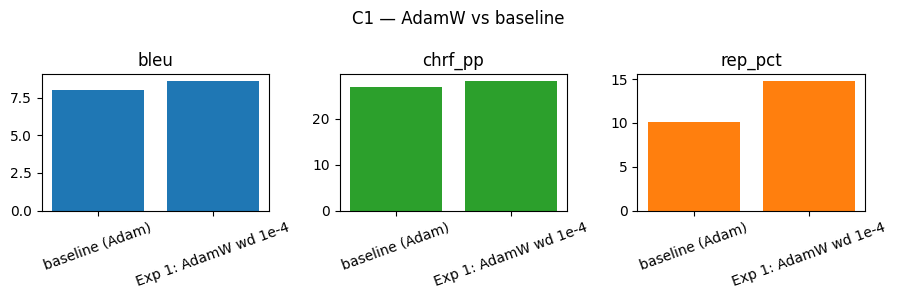

In [65]:
plot_metric_bars([baseline_res, adamw_res], "C1 — AdamW vs baseline", "outputs/figures/training_C1_adamw_vs_baseline.png")

AdamW improves over the baseline but not as much as plain-Adam weight decay (B2).

### C2: LR Warmup
Inverse-sqrt warmup then decay.

The configuration for this experiment. Only the changed line is different from the base.

In [66]:
warm_config = {
    **base_config,
    "name": "Exp 2: LR warmup",
    "category": "Optimization",
    "scheduler": "warmup",
    "checkpoint_dir": "outputs/checkpoints/C_optimization/exp2_lr_warmup",
}
warm_config

{'name': 'Exp 2: LR warmup',
 'category': 'Optimization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'warmup',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/C_optimization/exp2_lr_warmup'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [67]:
warm_model, warm_hist = load_or_train_checkpoint(warm_config)
print('parameters:', f'{sum(p.numel() for p in warm_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [68]:
pd.DataFrame(warm_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
54,55,3.763744,4.183820
55,56,3.757455,4.179939
56,57,3.752231,4.179027
57,58,3.745134,4.175378
58,59,3.739472,4.172590


The training and validation loss across the epochs.

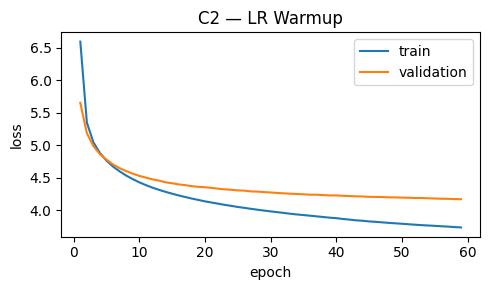

In [69]:
plot_loss(warm_hist, "C2 — LR Warmup", "outputs/figures/training_C2_lr_warmup_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [70]:
warm_res = subset_result(warm_config, warm_model)
results.append(warm_res)
pd.DataFrame([warm_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 2: LR warmup,Optimization,6.0988,23.665,15.0


This experiment shown next to the baseline.

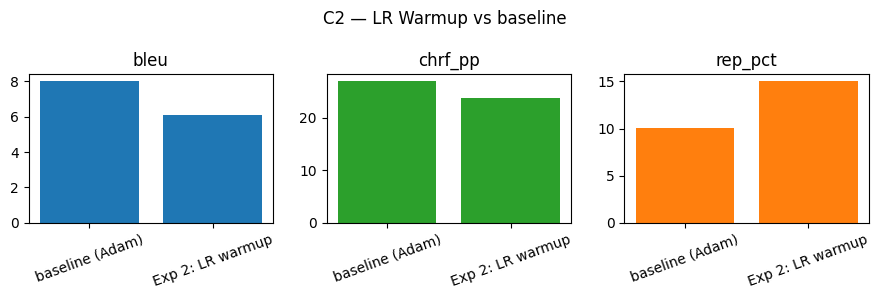

In [71]:
plot_metric_bars([baseline_res, warm_res], "C2 — LR Warmup vs baseline", "outputs/figures/training_C2_lr_warmup_vs_baseline.png")

Warmup decays the learning rate too far and underfits.

### C3: Cosine Scheduler
Cosine annealing of the learning rate.

The configuration for this experiment. Only the changed line is different from the base.

In [72]:
cos_config = {
    **base_config,
    "name": "Exp 3: cosine scheduler",
    "category": "Optimization",
    "scheduler": "cosine",
    "checkpoint_dir": "outputs/checkpoints/C_optimization/exp3_cosine_scheduler",
}
cos_config

{'name': 'Exp 3: cosine scheduler',
 'category': 'Optimization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'cosine',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/C_optimization/exp3_cosine_scheduler'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [73]:
cos_model, cos_hist = load_or_train_checkpoint(cos_config)
print('parameters:', f'{sum(p.numel() for p in cos_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [74]:
pd.DataFrame(cos_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
52,53,3.3932,4.0368
53,54,3.3905,4.0369
54,55,3.3889,4.0360
55,56,3.3863,4.0360
56,57,3.3826,4.0357


The training and validation loss across the epochs.

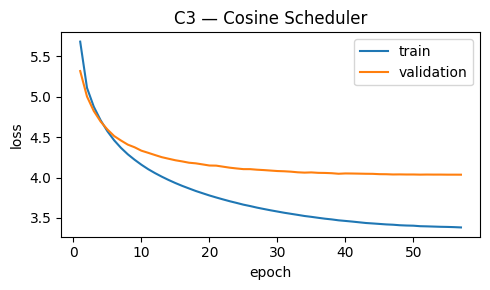

In [75]:
plot_loss(cos_hist, "C3 — Cosine Scheduler", "outputs/figures/training_C3_cosine_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [76]:
cos_res = subset_result(cos_config, cos_model)
results.append(cos_res)
pd.DataFrame([cos_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 3: cosine scheduler,Optimization,7.6453,26.5824,13.6


This experiment shown next to the baseline.

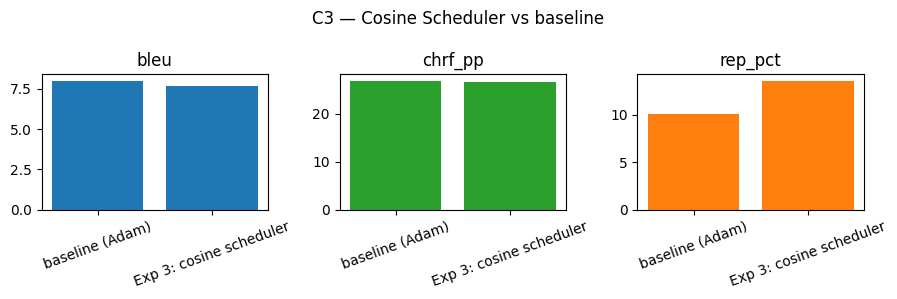

In [77]:
plot_metric_bars([baseline_res, cos_res], "C3 — Cosine Scheduler vs baseline", "outputs/figures/training_C3_cosine_vs_baseline.png")

Cosine annealing is about on par with the baseline.

### C4: Curriculum Learning

Curriculum learning starts the model on short, easy sentences and gradually grows the training set to include longer ones, following a competence schedule.

In [78]:
curr_config = {**base_config, "name": "Exp 4: curriculum", "category": "Optimization",
              "curriculum": True, "checkpoint_dir": "outputs/checkpoints/C_optimization/exp4_curriculum"}
curr_config

{'name': 'Exp 4: curriculum',
 'category': 'Optimization',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': True,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/C_optimization/exp4_curriculum'}

We load this model, or train it if the flags are on, and print its parameter count.

In [79]:
curr_model, curr_hist = load_or_train_checkpoint(curr_config)
print('parameters:', f'{sum(p.numel() for p in curr_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [80]:
pd.DataFrame(curr_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
54,55,3.3562,4.0046
55,56,3.3465,3.9989
56,57,3.3365,4.0006
57,58,3.3260,3.9983
58,59,3.3171,3.9946


The training and validation loss across the epochs.

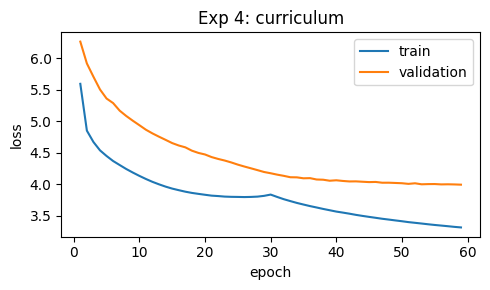

In [81]:
plot_loss(curr_hist, "Exp 4: curriculum", "outputs/figures/training_C4_curriculum_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [82]:
curr_res = subset_result(curr_config, curr_model)
results.append(curr_res)
pd.DataFrame([curr_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 4: curriculum,Optimization,8.0061,27.5239,11.2


An easy-to-hard training order. We compare it to the plain shuffled baseline.

## Experiment D: Architecture

### D1: Weight Tying
Tie the target embedding and the output projection (~25% fewer parameters).

The configuration for this experiment. Only the changed line is different from the base.

In [83]:
tie_config = {
    **base_config,
    "name": "Exp 1: weight tying",
    "category": "Architecture",
    "tie_weights": True,
    "checkpoint_dir": "outputs/checkpoints/D_architecture/exp1_weight_tying",
}
tie_config

{'name': 'Exp 1: weight tying',
 'category': 'Architecture',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': True,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp1_weight_tying'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [84]:
tie_model, tie_hist = load_or_train_checkpoint(tie_config)
print('parameters:', f'{sum(p.numel() for p in tie_model.parameters()):,}')

parameters: 2,982,208


The last few epochs of training, with the validation loss.

In [85]:
pd.DataFrame(tie_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.939258,4.026279
56,57,3.930699,4.024737
57,58,3.920269,4.016898
58,59,3.909925,4.012727
59,60,3.901255,4.010580


The training and validation loss across the epochs.

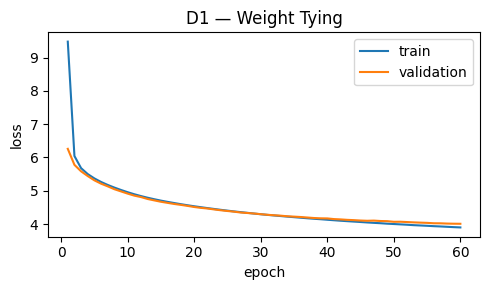

In [86]:
plot_loss(tie_hist, "D1 — Weight Tying", "outputs/figures/training_D1_weight_tying_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [87]:
tie_res = subset_result(tie_config, tie_model)
results.append(tie_res)
pd.DataFrame([tie_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 1: weight tying,Architecture,7.9453,26.5252,12.6


This experiment shown next to the baseline.

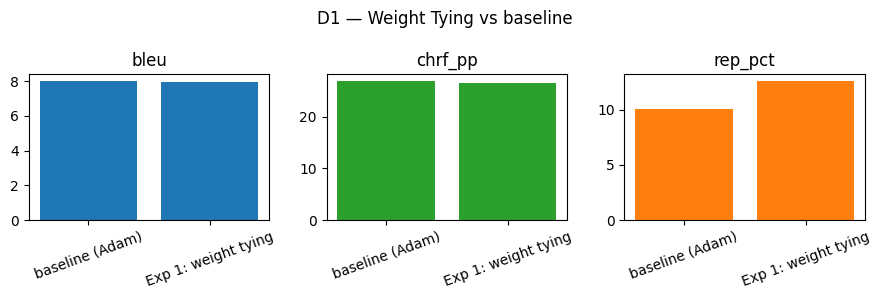

In [88]:
plot_metric_bars([baseline_res, tie_res], "D1 — Weight Tying vs baseline", "outputs/figures/training_D1_weight_tying_vs_baseline.png")

Weight tying keeps quality about the same with fewer parameters.

### D2: 4+4 Layers
A deeper model: 4 encoder and 4 decoder layers.

The configuration for this experiment. Only the changed line is different from the base.

In [89]:
deep_config = {
    **base_config,
    "name": "Exp 2: 4+4 layers",
    "category": "Architecture",
    "num_layers": 4,
    "checkpoint_dir": "outputs/checkpoints/D_architecture/exp2_layers",
}
deep_config

{'name': 'Exp 2: 4+4 layers',
 'category': 'Architecture',
 'd_model': 128,
 'num_layers': 4,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp2_layers'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [90]:
deep_model, deep_hist = load_or_train_checkpoint(deep_config)
print('parameters:', f'{sum(p.numel() for p in deep_model.parameters()):,}')

parameters: 4,931,904


The last few epochs of training, with the validation loss.

In [91]:
pd.DataFrame(deep_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
38,39,3.1321,3.8493
39,40,3.1168,3.8432
40,41,3.1031,3.8446
41,42,3.0902,3.8313
42,43,3.0769,3.8280


The training and validation loss across the epochs.

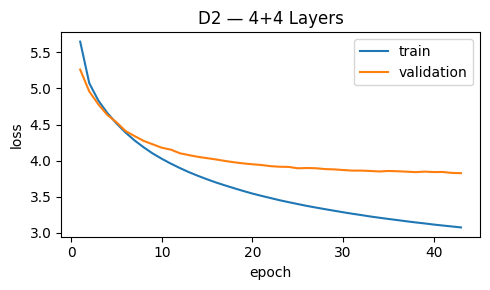

In [92]:
plot_loss(deep_hist, "D2 — 4+4 Layers", "outputs/figures/training_D2_layers_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [93]:
deep_res = subset_result(deep_config, deep_model)
results.append(deep_res)
pd.DataFrame([deep_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 2: 4+4 layers,Architecture,8.8564,29.311,13.4


This experiment shown next to the baseline.

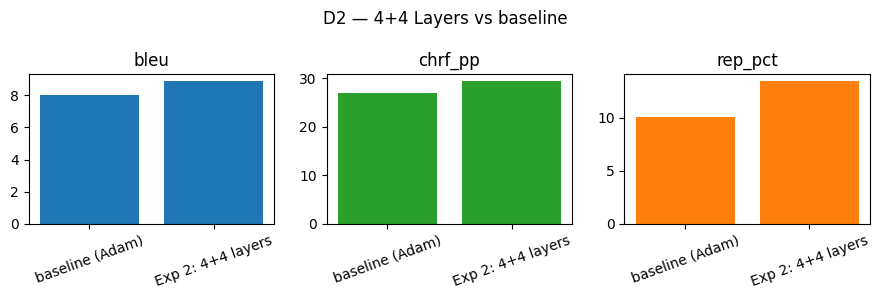

In [94]:
plot_metric_bars([baseline_res, deep_res], "D2 — 4+4 Layers vs baseline", "outputs/figures/training_D2_layers_vs_baseline.png")

More depth helps modestly but far less than weight decay.

### D3: d_model = 256
A wider model: embedding/hidden size 256.

The configuration for this experiment. Only the changed line is different from the base.

In [95]:
wide_config = {
    **base_config,
    "name": "Exp 3: d_model 256",
    "category": "Architecture",
    "d_model": 256,
    "checkpoint_dir": "outputs/checkpoints/D_architecture/exp3_embedding_size",
}
wide_config

{'name': 'Exp 3: d_model 256',
 'category': 'Architecture',
 'd_model': 256,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp3_embedding_size'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [96]:
wide_model, wide_hist = load_or_train_checkpoint(wide_config)
print('parameters:', f'{sum(p.numel() for p in wide_model.parameters()):,}')

parameters: 8,788,800


The last few epochs of training, with the validation loss.

In [97]:
pd.DataFrame(wide_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
14,15,3.3757,4.0848
15,16,3.3282,4.0862
16,17,3.2820,4.0846
17,18,3.2400,4.0802
18,19,3.1992,4.0794


The training and validation loss across the epochs.

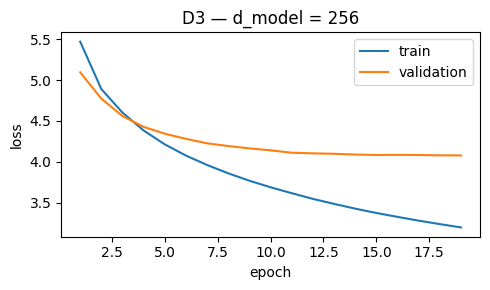

In [98]:
plot_loss(wide_hist, "D3 — d_model = 256", "outputs/figures/training_D3_dmodel_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [99]:
wide_res = subset_result(wide_config, wide_model)
results.append(wide_res)
pd.DataFrame([wide_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 3: d_model 256,Architecture,7.3306,25.7334,9.1


This experiment shown next to the baseline.

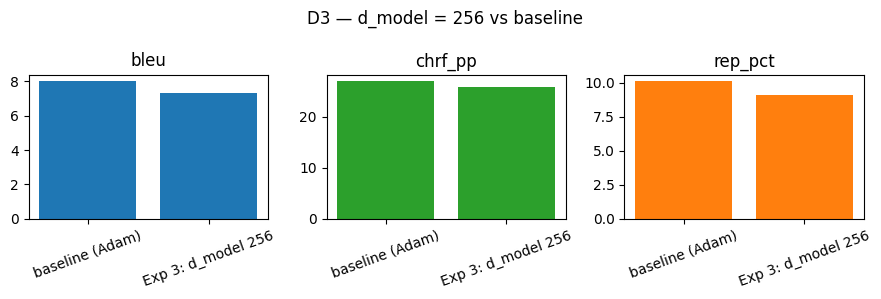

In [100]:
plot_metric_bars([baseline_res, wide_res], "D3 — d_model = 256 vs baseline", "outputs/figures/training_D3_dmodel_vs_baseline.png")

A wider model does not help here, it over-fits the small data.

### D4: 1 Layer

A shallower model with a single encoder and decoder layer, to see how much depth this task needs.

In [101]:
dep1_config = {**base_config, "name": "Exp 4: 1 layer", "category": "Architecture",
              "num_layers": 1, "checkpoint_dir": "outputs/checkpoints/D_architecture/exp4_depth1"}
dep1_config

{'name': 'Exp 4: 1 layer',
 'category': 'Architecture',
 'd_model': 128,
 'num_layers': 1,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp4_depth1'}

We load this model, or train it if the flags are on, and print its parameter count.

In [102]:
dep1_model, dep1_hist = load_or_train_checkpoint(dep1_config)
print('parameters:', f'{sum(p.numel() for p in dep1_model.parameters()):,}')

parameters: 3,543,360


The last few epochs of training, with the validation loss.

In [103]:
pd.DataFrame(dep1_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.6480,4.2435
56,57,3.6403,4.2405
57,58,3.6333,4.2430
58,59,3.6251,4.2350
59,60,3.6189,4.2345


The training and validation loss across the epochs.

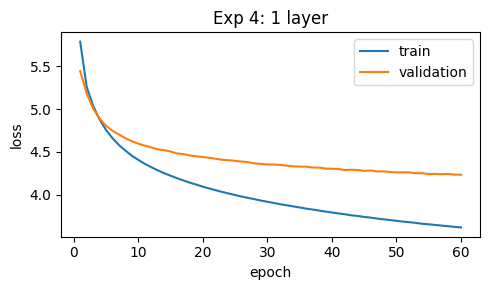

In [104]:
plot_loss(dep1_hist, "Exp 4: 1 layer", "outputs/figures/training_D4_depth1_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [105]:
dep1_res = subset_result(dep1_config, dep1_model)
results.append(dep1_res)
pd.DataFrame([dep1_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 4: 1 layer,Architecture,5.1813,20.1282,8.2


Half the depth of the baseline. Useful for the depth ablation the proposal listed.

### D5: 3 Layers

A deeper model with three encoder and decoder layers.

In [106]:
dep3_config = {**base_config, "name": "Exp 5: 3 layers", "category": "Architecture",
              "num_layers": 3, "checkpoint_dir": "outputs/checkpoints/D_architecture/exp5_depth3"}
dep3_config

{'name': 'Exp 5: 3 layers',
 'category': 'Architecture',
 'd_model': 128,
 'num_layers': 3,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp5_depth3'}

We load this model, or train it if the flags are on, and print its parameter count.

In [107]:
dep3_model, dep3_hist = load_or_train_checkpoint(dep3_config)
print('parameters:', f'{sum(p.numel() for p in dep3_model.parameters()):,}')

parameters: 4,469,056


The last few epochs of training, with the validation loss.

In [108]:
pd.DataFrame(dep3_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.0592,3.8742
56,57,3.0496,3.8733
57,58,3.0408,3.8748
58,59,3.0332,3.8719
59,60,3.0264,3.8698


The training and validation loss across the epochs.

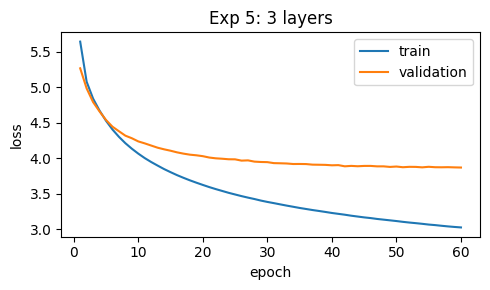

In [109]:
plot_loss(dep3_hist, "Exp 5: 3 layers", "outputs/figures/training_D5_depth3_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [110]:
dep3_res = subset_result(dep3_config, dep3_model)
results.append(dep3_res)
pd.DataFrame([dep3_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 5: 3 layers,Architecture,9.633,30.4201,13.8


More depth than the baseline; the depth ablation now covers 1, 2, 3 and 4 layers.

### D6: d_model = 64

A narrower model with half the embedding width, for the capacity trade-off.

In [111]:
wid64_config = {**base_config, "name": "Exp 6: d_model 64", "category": "Architecture",
              "d_model": 64, "checkpoint_dir": "outputs/checkpoints/D_architecture/exp6_width64"}
wid64_config

{'name': 'Exp 6: d_model 64',
 'category': 'Architecture',
 'd_model': 64,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp6_width64'}

We load this model, or train it if the flags are on, and print its parameter count.

In [112]:
wid64_model, wid64_hist = load_or_train_checkpoint(wid64_config)
print('parameters:', f'{sum(p.numel() for p in wid64_model.parameters()):,}')

parameters: 1,909,824


The last few epochs of training, with the validation loss.

In [113]:
pd.DataFrame(wid64_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.8066,4.0818
56,57,3.7977,4.0773
57,58,3.7924,4.0746
58,59,3.7857,4.0681
59,60,3.7787,4.0681


The training and validation loss across the epochs.

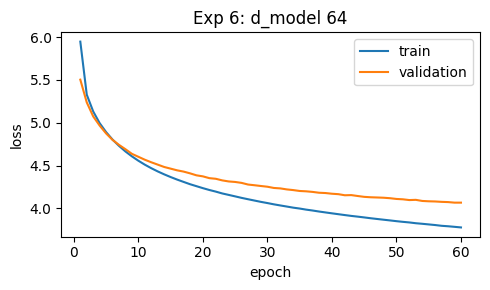

In [114]:
plot_loss(wid64_hist, "Exp 6: d_model 64", "outputs/figures/training_D6_width64_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [115]:
wid64_res = subset_result(wid64_config, wid64_model)
results.append(wid64_res)
pd.DataFrame([wid64_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 6: d_model 64,Architecture,7.1854,25.339,16.5


Half the width of the baseline; the width ablation now covers 64, 128 and 256.

### D7: GELU Activation

The encoder and decoder feed-forward blocks use a GELU activation instead of the default ReLU. GELU is the activation used in models like BERT and GPT and is sometimes a small win.

In [116]:
gelu_config = {**base_config, "name": "Exp 7: GELU activation", "category": "Architecture",
               "activation": "gelu", "checkpoint_dir": "outputs/checkpoints/D_architecture/exp7_gelu"}
gelu_config

{'name': 'Exp 7: GELU activation',
 'category': 'Architecture',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'gelu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/D_architecture/exp7_gelu'}

We load this model, or train it if the flags are on, and print its parameter count.

In [117]:
gelu_model, gelu_hist = load_or_train_checkpoint(gelu_config)
print('parameters:', f'{sum(p.numel() for p in gelu_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [118]:
pd.DataFrame(gelu_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
55,56,3.2008,3.9339
56,57,3.1954,3.9313
57,58,3.1865,3.9396
58,59,3.1779,3.9319
59,60,3.1720,3.9310


The training and validation loss across the epochs.

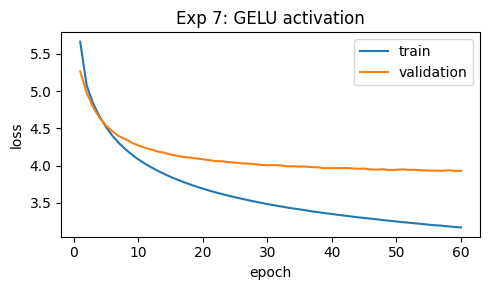

In [119]:
plot_loss(gelu_hist, "Exp 7: GELU activation", "outputs/figures/training_D7_gelu_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [120]:
gelu_res = subset_result(gelu_config, gelu_model)
results.append(gelu_res)
pd.DataFrame([gelu_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 7: GELU activation,Architecture,8.7843,28.6671,14.1


Same width and depth as the baseline, only the activation changes. We read whether GELU moves BLEU at all against the baseline.

## Experiment E: Data

How much does the amount of training data matter, and does focusing on rare words help? We retrain the same model on smaller random subsets and with rare-word oversampling.

### E1: 5K Training Pairs

The model trained on a random 5,000 pair subset instead of the full 50,000.

In [121]:
d5k_config = {**base_config, "name": "Exp 1: data 5K", "category": "Data",
              "train_size": 5000, "checkpoint_dir": "outputs/checkpoints/E_data/exp1_size5k"}
d5k_config

{'name': 'Exp 1: data 5K',
 'category': 'Data',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': 5000,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/E_data/exp1_size5k'}

We load this model, or train it if the flags are on, and print its parameter count.

In [122]:
d5k_model, d5k_hist = load_or_train_checkpoint(d5k_config)
print('parameters:', f'{sum(p.numel() for p in d5k_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [123]:
pd.DataFrame(d5k_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
13,14,4.6864,5.3235
14,15,4.6179,5.3204
15,16,4.5484,5.2993
16,17,4.4859,5.2992
17,18,4.4182,5.2919


The training and validation loss across the epochs.

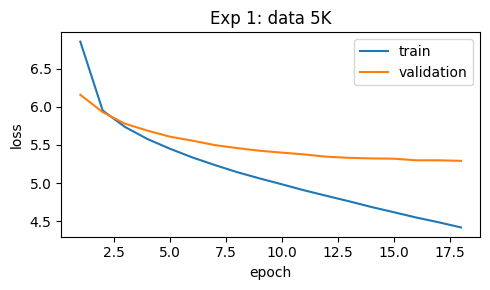

In [124]:
plot_loss(d5k_hist, "Exp 1: data 5K", "outputs/figures/training_E1_data5k_loss.png")

BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [125]:
d5k_res = subset_result(d5k_config, d5k_model)
results.append(d5k_res)
pd.DataFrame([d5k_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,Exp 1: data 5K,Data,1.6609,15.7683,14.0


The smallest data setting, the bottom of the learning curve.